# 01 · Dataset analysis

Explores the downloaded dataset using the project's own inspection code, so
everything shown here is exactly what the training pipeline sees.

**Prerequisites**

```
python scripts/download_dataset.py
python training/dataset_inspect.py
python training/prepare_splits.py
```


In [1]:
# Make the project's own modules importable, and apply the OpenMP fix that must
# run before torch is imported.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "backend"))
sys.path.insert(0, str(PROJECT_ROOT / "training"))

import app.core.runtime  # noqa: F401  (sets OMP env before numpy/torch)

import json
import numpy as np
import matplotlib.pyplot as plt

from app.core.config import settings

print("Project root:", PROJECT_ROOT)


Project root: D:\Data science projects\Plant disease detection


## The dataset report

Written by `training/dataset_inspect.py`. Nothing about the archive layout is assumed.

In [2]:
report = json.loads(settings.dataset_report_path.read_text(encoding="utf-8"))

print("Root      :", report["dataset"]["root"])
print("Classes   :", report["classes"]["count"])
print("Plants    :", report["classes"]["plant_count"])
print("Healthy   :", len(report["classes"]["healthy_classes"]))
print("Diseased  :", len(report["classes"]["diseased_classes"]))
for name, split in report["splits"].items():
    print(f"  {name:<8} {split['num_images']:>7,} images / {split['num_classes']:>3} classes")


Root      : D:\Data science projects\Plant disease detection\_kagglehub_cache\datasets\vipoooool\new-plant-diseases-dataset\versions\2
Classes   : 38
Plants    : 14
Healthy   : 12
Diseased  : 26
  train     70,295 images /  38 classes
  valid     17,572 images /  38 classes


## Class distribution and imbalance

The imbalance ratio decides which - if any - correction is applied.

min 1642 (Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot)
max 2022 (Soybean___healthy)
ratio 1.231   coefficient of variation 0.0564


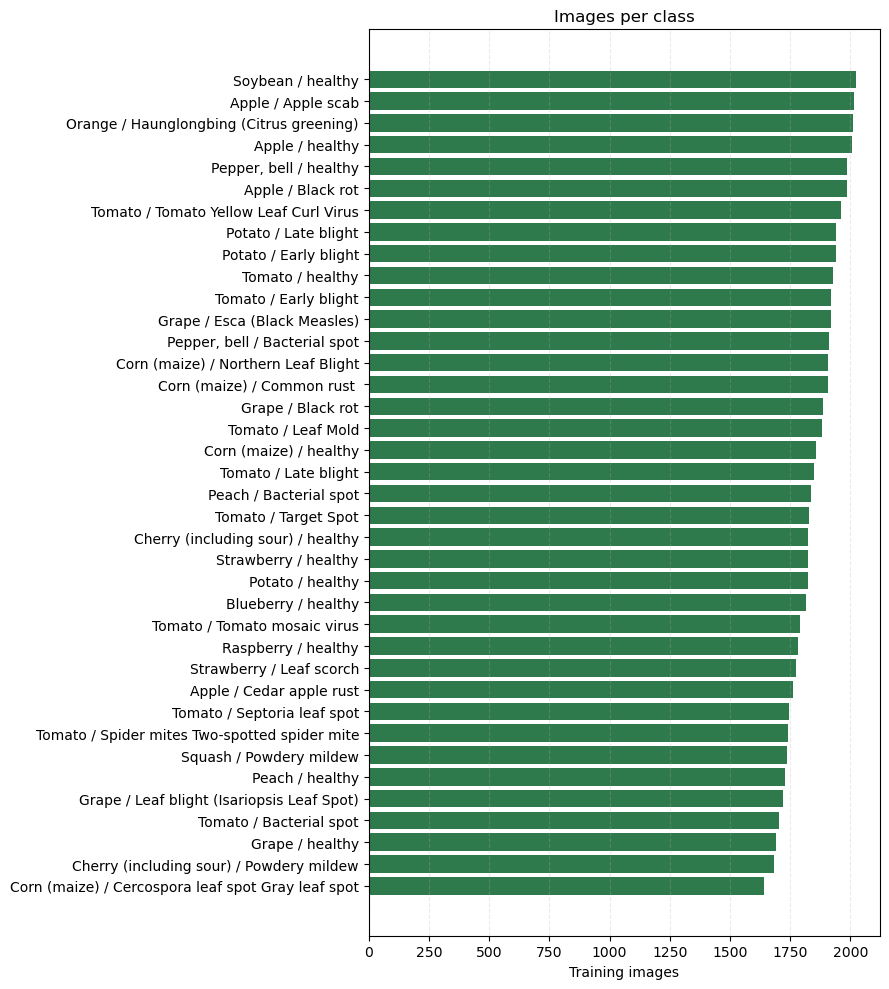

In [3]:
counts = report["splits"]["train"]["class_counts"]
imbalance = report["splits"]["train"]["imbalance"]

print(f"min {imbalance['min_count']} ({imbalance['min_class']})")
print(f"max {imbalance['max_count']} ({imbalance['max_class']})")
print(f"ratio {imbalance['imbalance_ratio']:.3f}   coefficient of variation {imbalance['coefficient_of_variation']:.4f}")

names = sorted(counts, key=counts.get)
fig, ax = plt.subplots(figsize=(9, 10))
ax.barh([n.replace("___", " / ").replace("_", " ") for n in names],
        [counts[n] for n in names], color="#2f7a4d")
ax.set_xlabel("Training images")
ax.set_title("Images per class")
ax.grid(axis="x", alpha=0.25, linestyle="--")
plt.tight_layout()
plt.show()


## Data-leakage check

The dataset ships pre-augmented, so the obvious question is whether augmented
copies of the same original photograph appear on both sides of the official
train/valid boundary. Perceptual hashes of a stratified sample from each split
are compared for collisions.

This is a *sampled* estimate, and pHash would not catch a rotated or flipped
augmentation of the same original - both limitations are real.


In [4]:
duplicates = report["duplicates"]
print("Method:", duplicates["method"])
print(f"Sampled per class: {duplicates['sampled_per_class']}")
print(f"Train duplicate groups: {duplicates['train']['duplicate_groups']}")

leak = duplicates.get("cross_split_leakage")
if leak:
    print(f"Train<->valid colliding hashes: {leak['colliding_hashes']}")
    print(f"Leak rate in sample: {leak['leak_rate_in_sample'] * 100:.3f}%")


Method: perceptual hash (pHash, 8x8 DCT), exact-hash collisions only
Sampled per class: 60
Train duplicate groups: 0
Train<->valid colliding hashes: 0
Leak rate in sample: 0.000%


## The split protocol and the imbalance decision

In [5]:
splits = json.loads(settings.splits_path.read_text(encoding="utf-8"))

print(splits["protocol"]["description"], "\n")
for name, info in splits["splits"].items():
    print(f"  {name:<12} {info['count']:>7,}")

print("\nImbalance strategy:", splits["imbalance"]["strategy"])
print("Reason:", splits["imbalance"]["reason"])


The official Kaggle train/ directory is split stratified into our train and validation sets. The official valid/ directory is never used for tuning and serves as the held-out test set for all reported numbers. 

  train         63,265
  val            7,030
  test          17,572
  train_bench   11,400
  val_bench      2,280
  test_bench     4,560

Imbalance strategy: none
Reason: Imbalance ratio 1.23 and coefficient of variation 0.056 are both small. Re-weighting a near-uniform distribution adds gradient noise without improving minority-class recall, so plain cross-entropy is used.


## Sample images

One example per class, straight from the training manifest.

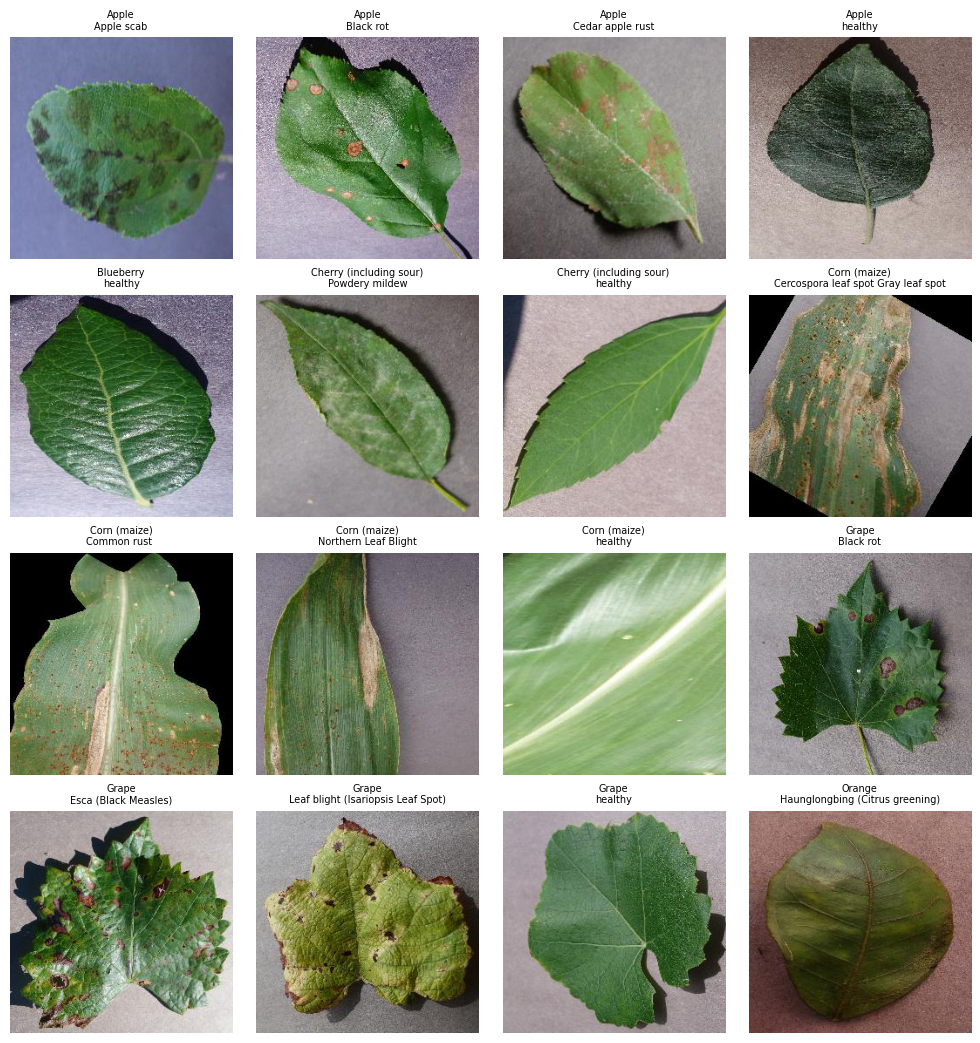

In [6]:
from PIL import Image
from app.ml.datasets import read_manifest

rows = read_manifest(settings.data_dir / "manifests" / "train.csv")
first_per_class = {}
for row in rows:
    first_per_class.setdefault(row.label, row)

labels = sorted(first_per_class)[:16]
fig, axes = plt.subplots(4, 4, figsize=(10, 10.5))
for ax, label in zip(axes.ravel(), labels):
    with Image.open(first_per_class[label].path) as img:
        ax.imshow(img.convert("RGB"))
    ax.set_title(first_per_class[label].class_name.replace("___", "\n").replace("_", " "), fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()


## Image-quality metrics on real leaves

The same checks the API runs before every prediction.

In [7]:
from app.ml.quality import analyse_image

for row in rows[:5]:
    with Image.open(row.path) as img:
        report_q = analyse_image(img)
    print(f"{row.class_name[:34]:<34} score {report_q.score:.3f}  "
          f"sharpness {report_q.metrics['blur_variance']:>7.0f}  "
          f"coherence {report_q.metrics['spatial_coherence']:.3f}  "
          f"plant-like {report_q.metrics['plant_like_fraction']:.2f}")


Apple___Apple_scab                 score 1.000  sharpness     444  coherence 0.943  plant-like 0.46
Apple___Apple_scab                 score 1.000  sharpness    5528  coherence 0.858  plant-like 0.66
Apple___Apple_scab                 score 1.000  sharpness     621  coherence 0.947  plant-like 0.32
Apple___Apple_scab                 score 1.000  sharpness    7404  coherence 0.791  plant-like 0.56
Apple___Apple_scab                 score 1.000  sharpness     306  coherence 0.983  plant-like 0.64
